# CPS 3840 Final Project Notebook  

By: Miguel Angel Soler, Alec Samonte, and Joseph Negron

## Brain Tumor MRI Classification with MobileNetV2 Ablation Study — Improved Test Version

**Project goal:** classify brain MRI scans into four classes using a consistent MobileNetV2-based deep learning pipeline.

This notebook is a separate test version designed to improve the ablation models while keeping the same required structure:

1. **Baseline MobileNetV2**  
2. **Baseline + Data Augmentation**  
3. **Baseline + Attention Module**  
4. **Proposed Model: MobileNetV2 + Data Augmentation + Attention + Careful Fine-Tuning**

**What changed in this improved test version:**
- Gentler MRI-safe augmentation
- Lower dropout so improved models do not underlearn
- Safer callbacks created fresh for each training run
- Lighter attention block
- Proposed model trains in two phases: frozen feature extractor first, then careful fine-tuning of only the last MobileNetV2 layers
- Final comparison table reports both **best validation accuracy** and **test accuracy**


## 1. Setup

This section imports the needed libraries, mounts Google Drive, and defines the dataset paths. The dataset is expected to be located at:

`/content/drive/MyDrive/Brain Tumor Dataset/archive`

Expected folder structure:

```text
archive/
├── Training/
│   ├── glioma/
│   ├── meningioma/
│   ├── notumor/
│   └── pituitary/
└── Testing/
    ├── glioma/
    ├── meningioma/
    ├── notumor/
    └── pituitary/
```

In [ ]:
# If running in Google Colab, mount Drive.
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 2. Dataset Path and Optional Local Copy

Training directly from Google Drive can sometimes be slow or unstable. The cell below copies the dataset from Drive into the Colab runtime. This usually makes image loading and training faster.

If you restart the runtime, you may need to copy it again.

In [ ]:
DRIVE_BASE_DIR = Path('/content/drive/MyDrive/Brain Tumor Dataset/archive')
LOCAL_BASE_DIR = Path('/content/brain_tumor_dataset')

USE_LOCAL_COPY = True

if USE_LOCAL_COPY:
    if not LOCAL_BASE_DIR.exists():
        print('Copying dataset from Drive to local Colab runtime...')
        shutil.copytree(DRIVE_BASE_DIR, LOCAL_BASE_DIR)
        print('Copy complete.')
    BASE_DIR = LOCAL_BASE_DIR
else:
    BASE_DIR = DRIVE_BASE_DIR

TRAIN_DIR = BASE_DIR / 'Training'
TEST_DIR = BASE_DIR / 'Testing'

print('BASE_DIR:', BASE_DIR)
print('Training folder exists:', TRAIN_DIR.exists())
print('Testing folder exists:', TEST_DIR.exists())
print('Training classes:', sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()]))
print('Testing classes:', sorted([p.name for p in TEST_DIR.iterdir() if p.is_dir()]))

Copying dataset from Drive to local Colab runtime...
Copy complete.
BASE_DIR: /content/brain_tumor_dataset
Training folder exists: True
Testing folder exists: True
Training classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Testing classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 3. Dataset Analysis

This section summarizes the dataset by counting the number of images per class in the training and testing folders. This helps identify class imbalance and confirms that the folder labels were read correctly.

In [ ]:
IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

def count_images_by_class(directory):
    rows = []
    for class_dir in sorted([p for p in Path(directory).iterdir() if p.is_dir()]):
        count = sum(1 for f in class_dir.rglob('*') if f.suffix.lower() in IMG_EXTENSIONS)
        rows.append({'class': class_dir.name, 'count': count})
    return pd.DataFrame(rows)

train_counts = count_images_by_class(TRAIN_DIR)
test_counts = count_images_by_class(TEST_DIR)

summary_counts = train_counts.merge(test_counts, on='class', suffixes=('_train', '_test'))
summary_counts['total'] = summary_counts['count_train'] + summary_counts['count_test']
summary_counts

,class,count_train,count_test,total
0,glioma,1400,400,1800
1,meningioma,1400,400,1800
2,notumor,1400,400,1800
3,pituitary,1400,400,1800


In [ ]:
print('Total training images:', train_counts['count'].sum())
print('Total testing images:', test_counts['count'].sum())
print('Number of classes:', len(train_counts))

Total training images: 5600
Total testing images: 1600
Number of classes: 4


### Visualization 1: Class Distribution

This chart shows whether the dataset is balanced or imbalanced across the four MRI classes.

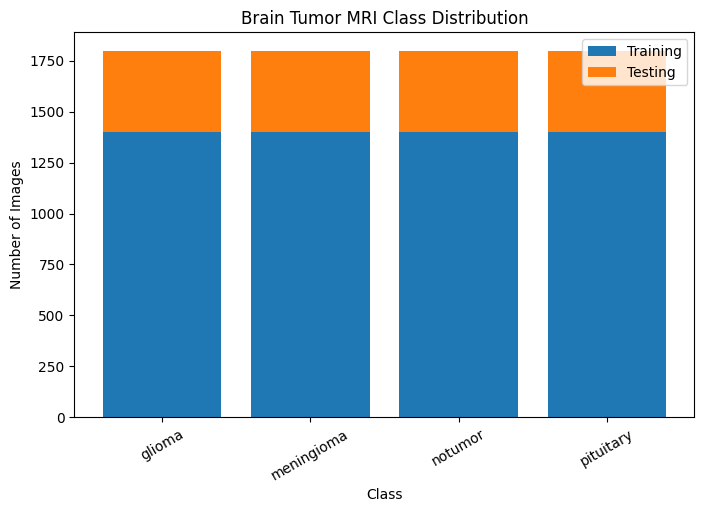

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(summary_counts['class'], summary_counts['count_train'], label='Training')
plt.bar(summary_counts['class'], summary_counts['count_test'], bottom=summary_counts['count_train'], label='Testing')
plt.title('Brain Tumor MRI Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=30)
plt.legend()
plt.show()

### Visualization 2: Sample MRI Images

The function below displays sample images from each class to visually inspect the dataset.

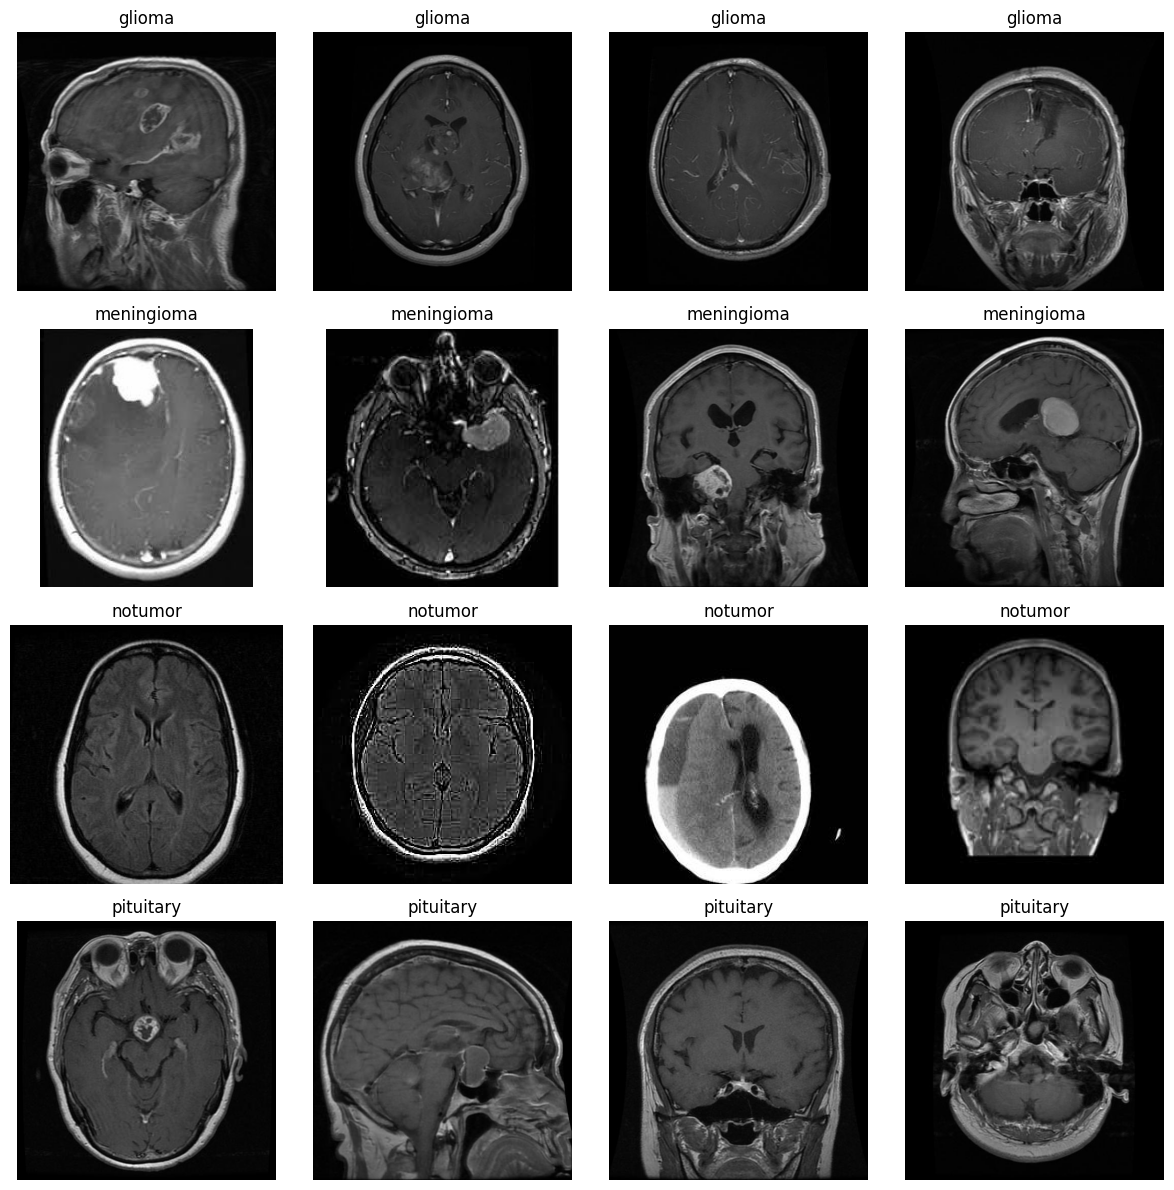

In [ ]:
def show_sample_images(directory, samples_per_class=4):
    class_dirs = sorted([p for p in Path(directory).iterdir() if p.is_dir()])
    plt.figure(figsize=(samples_per_class * 3, len(class_dirs) * 3))
    plot_idx = 1

    for class_dir in class_dirs:
        image_files = [f for f in class_dir.rglob('*') if f.suffix.lower() in IMG_EXTENSIONS]
        selected = random.sample(image_files, min(samples_per_class, len(image_files)))
        for img_path in selected:
            img = Image.open(img_path).convert('RGB')
            plt.subplot(len(class_dirs), samples_per_class, plot_idx)
            plt.imshow(img)
            plt.title(class_dir.name)
            plt.axis('off')
            plot_idx += 1

    plt.tight_layout()
    plt.show()

show_sample_images(TRAIN_DIR, samples_per_class=4)

### Visualization 3: Image Size Distribution

Even though the model will resize images to 224×224, checking the original image sizes helps us understand variation in the raw dataset.

In [ ]:
def collect_image_sizes(directory, max_images=1000):
    all_images = [f for f in Path(directory).rglob('*') if f.suffix.lower() in IMG_EXTENSIONS]
    selected = random.sample(all_images, min(max_images, len(all_images)))
    sizes = []
    for img_path in selected:
        try:
            with Image.open(img_path) as img:
                sizes.append(img.size)  # (width, height)
        except Exception as e:
            print('Skipped:', img_path, e)
    return pd.DataFrame(sizes, columns=['width', 'height'])

sizes_df = collect_image_sizes(TRAIN_DIR, max_images=1000)
sizes_df.describe()

,width,height
count,1000.00000,1000.000000
mean,459.98700,464.115000
std,127.35761,123.856717
min,150.00000,168.000000
25%,512.00000,512.000000
50%,512.00000,512.000000
75%,512.00000,512.000000
max,1365.00000,1427.000000


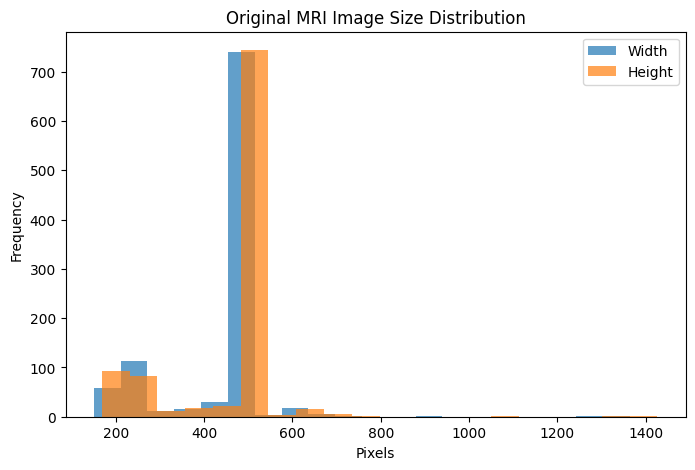

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(sizes_df['width'], bins=20, alpha=0.7, label='Width')
plt.hist(sizes_df['height'], bins=20, alpha=0.7, label='Height')
plt.title('Original MRI Image Size Distribution')
plt.xlabel('Pixels')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## 4. Data Loading with `image_dataset_from_directory`

We create training, validation, and testing datasets.

- Training set: used to fit the model
- Validation set: used for hyperparameter tuning and model selection
- Test set: used only for final evaluation

The images are resized to 224×224 because MobileNetV2 expects this common input size.

In [ ]:
IMG_SIZE = (224, 224)
INPUT_SHAPE = IMG_SIZE + (3,)
BATCH_SIZE = 32
VAL_SPLIT = 0.2

train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print('Class names:', class_names)
print('Number of classes:', NUM_CLASSES)
print('Input shape:', INPUT_SHAPE)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4
Input shape: (224, 224, 3)


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

## 5. Helper Functions for Training and Evaluation

These functions keep the notebook organized and make all models evaluate in the same way.

In [ ]:
RESULTS = []
HISTORIES = {}

def get_callbacks(patience=2):
    """Create fresh callbacks for each model training run."""
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=1,
            min_lr=1e-7,
            verbose=1
        )
    ]

# Backward-compatible name in case an earlier cell still references callbacks_common.
callbacks_common = get_callbacks()

def combine_histories(*histories):
    """Combine multiple Keras History objects into one dictionary-like history object."""
    combined = {}
    for hist in histories:
        for key, values in hist.history.items():
            combined.setdefault(key, []).extend(values)

    class CombinedHistory:
        pass

    output = CombinedHistory()
    output.history = combined
    return output


def plot_history(history, title):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(8, 5))
    plt.plot(hist['accuracy'], label='Train Accuracy')
    plt.plot(hist['val_accuracy'], label='Validation Accuracy')
    plt.title(title + ' - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(hist['loss'], label='Train Loss')
    plt.plot(hist['val_loss'], label='Validation Loss')
    plt.title(title + ' - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


def evaluate_model(model, dataset, model_name):
    loss, acc = model.evaluate(dataset, verbose=0)
    print(f'{model_name} Test Accuracy: {acc:.4f}')
    print(f'{model_name} Test Loss: {loss:.4f}')

    y_prob = model.predict(dataset, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for x, y in dataset], axis=0)

    print('Classification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(xticks_rotation=45)
    plt.title(model_name + ' Confusion Matrix')
    plt.show()

    macro_f1 = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)['macro avg']['f1-score']
    RESULTS.append({
        'Model': model_name,
        'Test Accuracy': acc,
        'Test Loss': loss,
        'Macro F1': macro_f1
    })
    return acc, loss, macro_f1


## 6. Model Builder: MobileNetV2-Based Classifier

All experiments in this notebook use the same base model family: **MobileNetV2**.

The differences between experiments are controlled by parameters:

- `use_augmentation`: adds data augmentation before preprocessing
- `use_attention`: adds a squeeze-and-excitation attention block
- `dropout_rate`: controls regularization
- `train_base`: controls whether the MobileNetV2 backbone is frozen or fine-tuned

This lets us perform a clean ablation study while staying within one model family.

In [ ]:
# ============================================================
# Model Building Blocks: Gentle Augmentation + Lightweight Attention
# ============================================================

# MRI-safe augmentation: intentionally gentle because strong rotations/zooms can distort medical patterns.
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomContrast(0.05),
], name='gentle_data_augmentation')


def se_attention_block(inputs, reduction_ratio=8, name='se_attention'):
    """Lightweight Squeeze-and-Excitation attention block for channel-wise feature weighting."""
    channels = int(inputs.shape[-1])
    reduced_channels = max(channels // reduction_ratio, 1)

    x = layers.GlobalAveragePooling2D(name=name + '_gap')(inputs)
    x = layers.Dense(reduced_channels, activation='relu', name=name + '_dense1')(x)
    x = layers.Dense(channels, activation='sigmoid', name=name + '_dense2')(x)
    x = layers.Reshape((1, 1, channels), name=name + '_reshape')(x)
    return layers.Multiply(name=name + '_scale')([inputs, x])


def build_mobilenetv2_model(
    input_shape=INPUT_SHAPE,
    num_classes=NUM_CLASSES,
    dropout_rate=0.2,
    learning_rate=1e-4,
    use_augmentation=False,
    use_attention=False,
    train_base=False,
    fine_tune_at=None,
    model_name='mobilenetv2_model'
):
    inputs = keras.Input(shape=input_shape, name=model_name + '_input')
    x = inputs

    if use_augmentation:
        x = data_augmentation(x)

    # MobileNetV2 preprocessing scales inputs to the range expected by the pretrained model.
    x = preprocess_input(x)

    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        name=model_name + '_backbone'
    )

    base_model.trainable = train_base

    if train_base and fine_tune_at is not None:
        # Freeze earlier layers and fine-tune later layers.
        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False
        for layer in base_model.layers[fine_tune_at:]:
            # Keep batch normalization frozen for more stable transfer learning.
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False
            else:
                layer.trainable = True

    # Use training=False so MobileNetV2 batch normalization layers remain stable during transfer learning.
    x = base_model(x, training=False)

    if use_attention:
        x = se_attention_block(x)

    x = layers.GlobalAveragePooling2D(name=model_name + '_gap')(x)
    x = layers.BatchNormalization(name=model_name + '_bn')(x)
    x = layers.Dropout(dropout_rate, name=model_name + '_dropout1')(x)
    x = layers.Dense(128, activation='relu', name=model_name + '_dense128')(x)
    x = layers.Dropout(dropout_rate / 2, name=model_name + '_dropout2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name=model_name + '_output')(x)

    model = keras.Model(inputs, outputs, name=model_name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


## 7. Task 2: Baseline Model — MobileNetV2

The baseline model uses MobileNetV2 as a pretrained feature extractor with the backbone frozen. It does **not** use data augmentation or attention.

This is a strong baseline for image classification because MobileNetV2 has already learned general visual patterns from ImageNet, while the final layer is adapted to the four brain MRI classes.

In [ ]:
baseline_model = build_mobilenetv2_model(
    dropout_rate=0.2,
    learning_rate=1e-4,
    use_augmentation=False,
    use_attention=False,
    train_base=False,
    model_name='baseline_mobilenetv2'
)

baseline_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "baseline_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ baseline_mobilenetv2_input      │ (None, 224, 224, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ baseline_mobilenetv2_backbone   │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ baseline_mobilenetv2_gap        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ baseline_mobilenetv2_bn         │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ baseline_mobilenetv2_dropout1   │ (None, 1280)           │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ baseline_mobilenetv2_dense128   │ (None, 128)            │       163,968 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ baseline_mobilenetv2_dropout2   │ (None, 128)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ baseline_mobilenetv2_output     │ (None, 4)              │           516 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,588 (9.26 MB)

 Trainable params: 167,044 (652.52 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

Epoch 1/6
140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 102ms/step - accuracy: 0.6973 - loss: 0.7941 - val_accuracy: 0.8732 - val_loss: 0.4290 - learning_rate: 1.0000e-04
Epoch 2/6
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.8272 - loss: 0.4510 - val_accuracy: 0.9062 - val_loss: 0.3017 - learning_rate: 1.0000e-04
Epoch 3/6
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.8672 - loss: 0.3690 - val_accuracy: 0.9250 - val_loss: 0.2514 - learning_rate: 1.0000e-04
Epoch 4/6
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.8844 - loss: 0.3155 - val_accuracy: 0.9295 - val_loss: 0.2235 - learning_rate: 1.0000e-04
Epoch 5/6
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.8998 - loss: 0.2687 - val_accuracy: 0.9402 - val_loss: 0.2014 - learning_rate: 1.0000e-04
Epoch 6/6
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.9103 - loss: 0.2414 - val_accuracy: 0.9393 - val_loss: 0.1921 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 6.


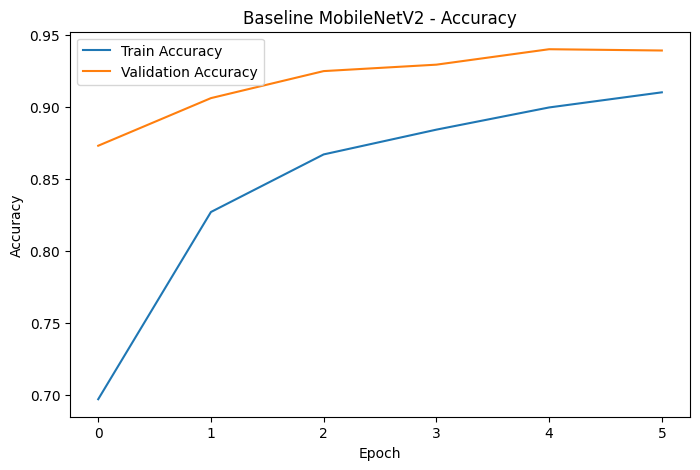

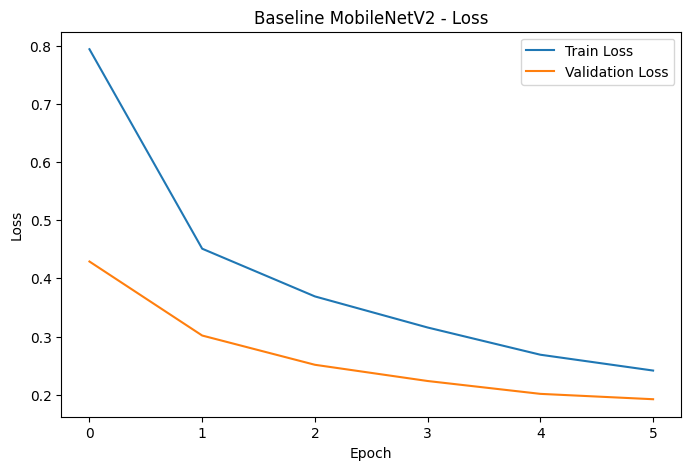

In [ ]:
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    callbacks=get_callbacks(patience=2)
)

HISTORIES['Baseline MobileNetV2'] = history_baseline
plot_history(history_baseline, 'Baseline MobileNetV2')


Baseline MobileNetV2 Test Accuracy: 0.8606
Baseline MobileNetV2 Test Loss: 0.4568
Classification Report:
              precision    recall  f1-score   support

      glioma     0.9091    0.7000    0.7910       400
  meningioma     0.7566    0.7850    0.7706       400
     notumor     0.8800    0.9900    0.9318       400
   pituitary     0.9063    0.9675    0.9359       400

    accuracy                         0.8606      1600
   macro avg     0.8630    0.8606    0.8573      1600
weighted avg     0.8630    0.8606    0.8573      1600



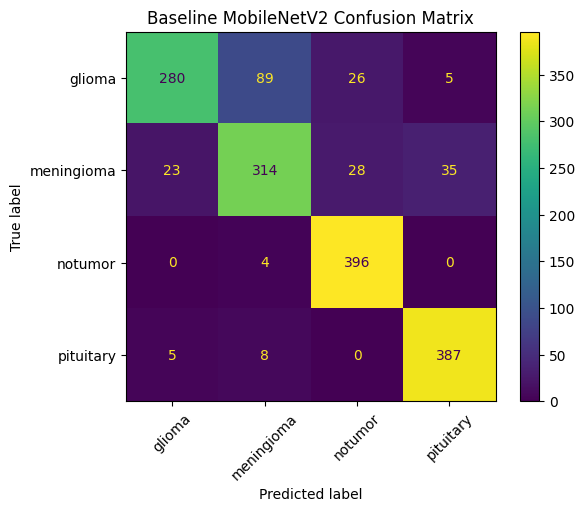

(0.8606250286102295, 0.45675840973854065, 0.857297560857584)

In [ ]:
evaluate_model(baseline_model, test_ds, 'Baseline MobileNetV2')

In [ ]:
# This is to include Early Stopping to improve run times.

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=1,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stop, reduce_lr]

## 8. Hyperparameter Tuning

The project requires validation-based tuning of at least two hyperparameters. Here we tune:

1. Learning rate  
2. Dropout rate  

To save time, each configuration runs for a small number of epochs. The best validation accuracy guides the final model choice.

In [ ]:
# ============================================================
# Hyperparameter Tuning: Small Manual Search Instead of Nested Loop
# ============================================================

# This tunes TWO hyperparameters without an expensive nested grid search:
# 1. learning_rate
# 2. dropout_rate

# Avoid 1e-3 for pretrained MobileNetV2 because it can be too aggressive.
tuning_experiments = [
    {'experiment': 'Trial 1', 'learning_rate': 1e-4, 'dropout_rate': 0.2},
    {'experiment': 'Trial 2', 'learning_rate': 5e-5, 'dropout_rate': 0.2},
    {'experiment': 'Trial 3', 'learning_rate': 1e-4, 'dropout_rate': 0.15},
]

tuning_results = []
TUNING_EPOCHS = 2

for params in tuning_experiments:
    print('' + '='*60)
    print(f"Running {params['experiment']}")
    print(f"Learning Rate: {params['learning_rate']}")
    print(f"Dropout Rate: {params['dropout_rate']}")
    print('='*60)

    tf.keras.backend.clear_session()

    model = build_mobilenetv2_model(
        input_shape=INPUT_SHAPE,
        num_classes=NUM_CLASSES,
        dropout_rate=params['dropout_rate'],
        learning_rate=params['learning_rate'],
        use_augmentation=False,
        use_attention=False,
        train_base=False,
        model_name='tuning_model'
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=TUNING_EPOCHS,
        callbacks=get_callbacks(patience=1),
        verbose=1
    )

    tuning_results.append({
        'Experiment': params['experiment'],
        'Learning Rate': params['learning_rate'],
        'Dropout Rate': params['dropout_rate'],
        'Best Validation Accuracy': max(history.history['val_accuracy']),
        'Best Validation Loss': min(history.history['val_loss'])
    })

tuning_results_df = pd.DataFrame(tuning_results)
tuning_results_df = tuning_results_df.sort_values(
    by='Best Validation Accuracy',
    ascending=False
).reset_index(drop=True)

display(tuning_results_df)

BEST_LR = float(tuning_results_df.loc[0, 'Learning Rate'])
BEST_DROPOUT = float(tuning_results_df.loc[0, 'Dropout Rate'])

print('Best Hyperparameters Selected:')
print(f'BEST_LR = {BEST_LR}')
print(f'BEST_DROPOUT = {BEST_DROPOUT}')


Running Trial 1
Learning Rate: 0.0001
Dropout Rate: 0.2
Epoch 1/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - accuracy: 0.6605 - loss: 0.9041 - val_accuracy: 0.8420 - val_loss: 0.4790 - learning_rate: 1.0000e-04
Epoch 2/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.8257 - loss: 0.4844 - val_accuracy: 0.8911 - val_loss: 0.3238 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 2.
Running Trial 2
Learning Rate: 5e-05
Dropout Rate: 0.2
Epoch 1/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 123ms/step - accuracy: 0.6112 - loss: 0.9949 - val_accuracy: 0.8036 - val_loss: 0.6190 - learning_rate: 5.0000e-05
Epoch 2/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.7737 - loss: 0.6070 - val_accuracy: 0.8554 - val_loss: 0.4251 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 2.
Running Trial 3
Learning Rate: 0.0001
Dropout Rate: 0.15
Epoch 1/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 95ms/step - accuracy: 0.6938 - loss: 0.7768

,Experiment,Learning Rate,Dropout Rate,Best Validation Accuracy,Best Validation Loss
0,Trial 3,0.00010,0.15,0.896429,0.305118
1,Trial 1,0.00010,0.20,0.891071,0.323827
2,Trial 2,0.00005,0.20,0.855357,0.425094


Best Hyperparameters Selected:
BEST_LR = 0.0001
BEST_DROPOUT = 0.15


## 9. Task 3 / Task 4 Ablation Model 1: Baseline + Data Augmentation

This model keeps the same MobileNetV2 baseline, but adds training-time data augmentation. The purpose is to test whether artificial image variation improves generalization.

Epoch 1/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 95ms/step - accuracy: 0.6946 - loss: 0.7896 - val_accuracy: 0.7991 - val_loss: 0.5421 - learning_rate: 1.0000e-04
Epoch 2/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.8355 - loss: 0.4613 - val_accuracy: 0.8464 - val_loss: 0.4082 - learning_rate: 1.0000e-04
Epoch 3/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.8578 - loss: 0.3878 - val_accuracy: 0.8795 - val_loss: 0.3380 - learning_rate: 1.0000e-04
Epoch 4/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.8754 - loss: 0.3330 - val_accuracy: 0.8946 - val_loss: 0.3144 - learning_rate: 1.0000e-04
Epoch 5/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.8835 - loss: 0.3135 - val_accuracy: 0.9036 - val_loss: 0.2868 - learning_rate: 1.0000e-04
Epoch 6/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.8958 - loss: 0.2782 - val_accuracy: 0.9098 - val_loss: 0.2856 - learning_rate: 1.0000e-04
Epoch 7/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - acc

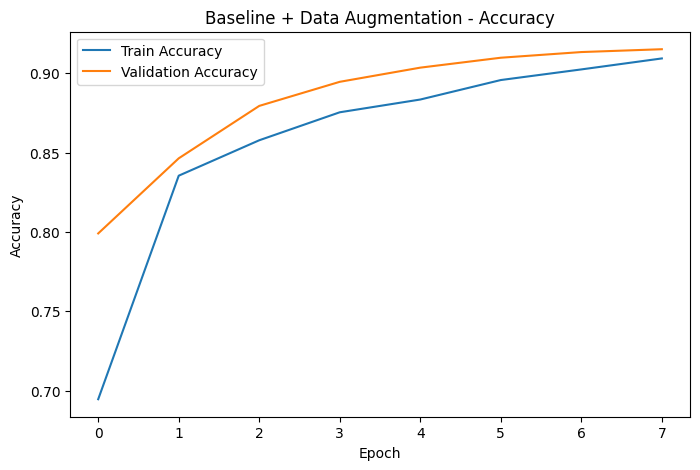

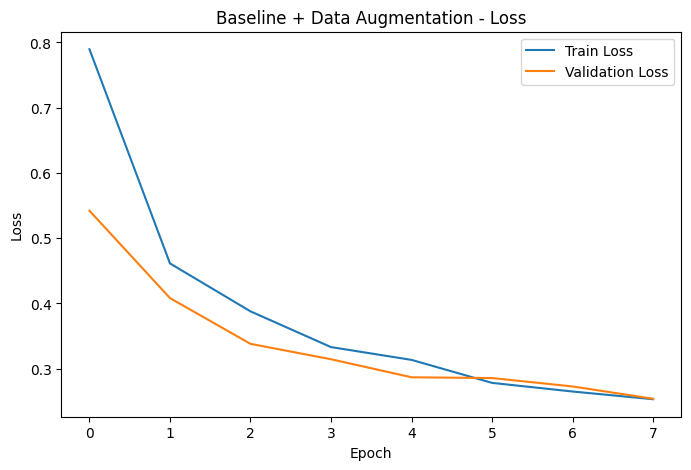

In [ ]:
aug_model = build_mobilenetv2_model(
    dropout_rate=BEST_DROPOUT,
    learning_rate=BEST_LR,
    use_augmentation=True,
    use_attention=False,
    train_base=False,
    model_name='mobilenetv2_plus_augmentation'
)

history_aug = aug_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=get_callbacks(patience=2)
)

HISTORIES['Baseline + Data Augmentation'] = history_aug
plot_history(history_aug, 'Baseline + Data Augmentation')


Baseline + Data Augmentation Test Accuracy: 0.8306
Baseline + Data Augmentation Test Loss: 0.5254
Classification Report:
              precision    recall  f1-score   support

      glioma     0.9141    0.6650    0.7699       400
  meningioma     0.7500    0.6975    0.7228       400
     notumor     0.8849    0.9800    0.9300       400
   pituitary     0.7935    0.9800    0.8770       400

    accuracy                         0.8306      1600
   macro avg     0.8356    0.8306    0.8249      1600
weighted avg     0.8356    0.8306    0.8249      1600



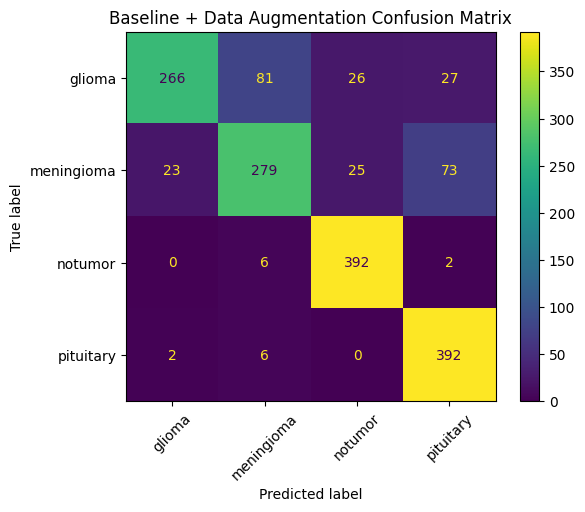

(0.8306249976158142, 0.5253959894180298, 0.824916495451075)

In [ ]:
evaluate_model(aug_model, test_ds, 'Baseline + Data Augmentation')

## 10. Task 3 / Task 4 Ablation Model 2: Baseline + Attention Module

This model adds a **Squeeze-and-Excitation attention module** after the MobileNetV2 convolutional feature extractor. The attention module learns which feature channels should be emphasized before classification.

Epoch 1/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 94ms/step - accuracy: 0.7132 - loss: 0.7556 - val_accuracy: 0.8679 - val_loss: 0.5384 - learning_rate: 1.0000e-04
Epoch 2/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.8618 - loss: 0.3914 - val_accuracy: 0.9089 - val_loss: 0.3103 - learning_rate: 1.0000e-04
Epoch 3/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.8940 - loss: 0.2959 - val_accuracy: 0.9268 - val_loss: 0.2232 - learning_rate: 1.0000e-04
Epoch 4/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.9116 - loss: 0.2367 - val_accuracy: 0.9420 - val_loss: 0.1865 - learning_rate: 1.0000e-04
Epoch 5/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9321 - loss: 0.1911 - val_accuracy: 0.9455 - val_loss: 0.1644 - learning_rate: 1.0000e-04
Epoch 6/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9400 - loss: 0.1596 - val_accuracy: 0.9473 - val_loss: 0.1493 - learning_rate: 1.0000e-04
Epoch 7/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy

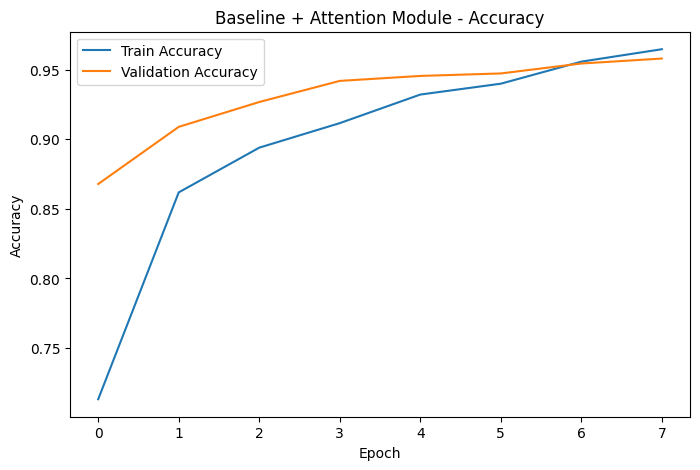

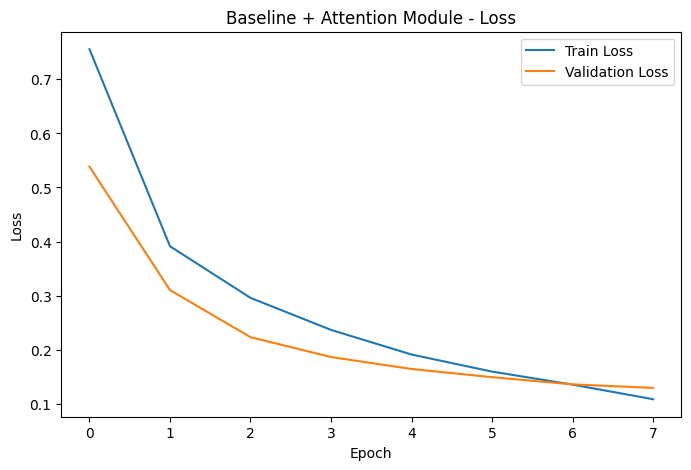

In [ ]:
attention_model = build_mobilenetv2_model(
    dropout_rate=BEST_DROPOUT,
    learning_rate=BEST_LR,
    use_augmentation=False,
    use_attention=True,
    train_base=False,
    model_name='mobilenetv2_plus_attention'
)

history_attention = attention_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=get_callbacks(patience=2)
)

HISTORIES['Baseline + Attention Module'] = history_attention
plot_history(history_attention, 'Baseline + Attention Module')


Baseline + Attention Module Test Accuracy: 0.8944
Baseline + Attention Module Test Loss: 0.4224
Classification Report:
              precision    recall  f1-score   support

      glioma     0.9472    0.7175    0.8165       400
  meningioma     0.7840    0.9075    0.8413       400
     notumor     0.9190    0.9925    0.9543       400
   pituitary     0.9552    0.9600    0.9576       400

    accuracy                         0.8944      1600
   macro avg     0.9014    0.8944    0.8924      1600
weighted avg     0.9014    0.8944    0.8924      1600



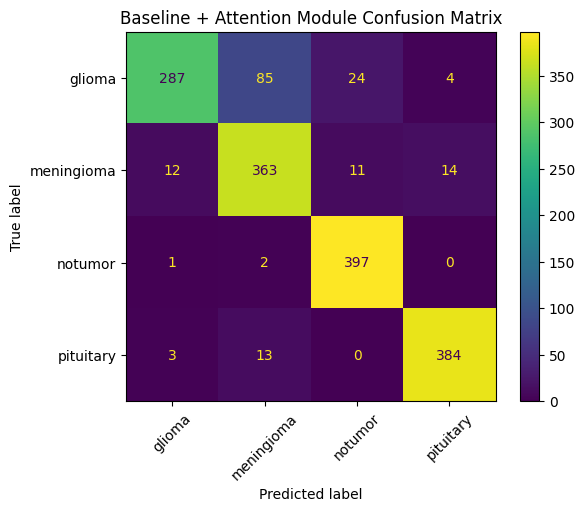

(0.8943750262260437, 0.42238321900367737, 0.892421266946893)

In [ ]:
evaluate_model(attention_model, test_ds, 'Baseline + Attention Module')

## 11. Proposed Model: MobileNetV2 + Data Augmentation + Attention + Careful Fine-Tuning

The proposed final model combines the improvements:

- MobileNetV2 backbone
- Gentle data augmentation
- Squeeze-and-Excitation attention module
- Lower dropout regularization
- Careful fine-tuning of only the last MobileNetV2 layers

This version trains in two phases:
1. Train only the new classification/attention head while MobileNetV2 is frozen.
2. Unfreeze only the last 20 layers of MobileNetV2 and fine-tune with a very small learning rate.


In [ ]:
proposed_model = build_mobilenetv2_model(
    dropout_rate=BEST_DROPOUT,
    learning_rate=BEST_LR,
    use_augmentation=True,
    use_attention=True,
    train_base=False,  # Phase 1: keep MobileNetV2 frozen
    model_name='proposed_mobilenetv2_aug_attention_finetune'
)

proposed_model.summary()


Model: "proposed_mobilenetv2_aug_attention_finetune"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ proposed_mobilenet… │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gentle_data_augmen… │ (None, 224, 224,  │          0 │ proposed_mobilen… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_3       │ (None, 224, 224,  │          0 │ gentle_data_augm… │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_3          │ (None, 224, 224,  │          0 │ true_divide_3[0]… │
│ (Subtract)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proposed_mobilenet… │ (None, 7, 7,      │  2,257,984 │ subtract_3[0][0]  │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se_attention_gap    │ (None, 1280)      │          0 │ proposed_mobilen… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se_attention_dense1 │ (None, 160)       │    204,960 │ se_attention_gap… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se_attention_dense2 │ (None, 1280)      │    206,080 │ se_attention_den… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se_attention_resha… │ (None, 1, 1,      │          0 │ se_attention_den… │
│ (Reshape)           │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se_attention_scale  │ (None, 7, 7,      │          0 │ proposed_mobilen… │
│ (Multiply)          │ 1280)             │            │ se_attention_res… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proposed_mobilenet… │ (None, 1280)      │          0 │ se_attention_sca… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proposed_mobilenet… │ (None, 1280)      │      5,120 │ proposed_mobilen… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proposed_mobilenet… │ (None, 1280)      │          0 │ proposed_mobilen… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proposed_mobilenet… │ (None, 128)       │    163,968 │ proposed_mobilen… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proposed_mobilenet… │ (None, 128)       │          0 │ proposed_mobilen… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proposed_mobilenet… │ (None, 4)         │        516 │ proposed_mobilen… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,838,628 (10.83 MB)

 Trainable params: 578,084 (2.21 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

Epoch 1/6
140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - accuracy: 0.6940 - loss: 0.8170 - val_accuracy: 0.8036 - val_loss: 0.6404 - learning_rate: 1.0000e-04
Epoch 2/6
140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 82ms/step - accuracy: 0.8402 - loss: 0.4310 - val_accuracy: 0.8768 - val_loss: 0.3913 - learning_rate: 1.0000e-04
Epoch 3/6
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.8629 - loss: 0.3577 - val_accuracy: 0.9000 - val_loss: 0.3140 - learning_rate: 1.0000e-04
Epoch 4/6
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.8855 - loss: 0.3141 - val_accuracy: 0.9036 - val_loss: 0.2940 - learning_rate: 1.0000e-04
Epoch 5/6
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.9038 - loss: 0.2639 - val_accuracy: 0.9196 - val_loss: 0.2481 - learning_rate: 1.0000e-04
Epoch 6/6
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9072 - loss: 0.2567
Epoch 6: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accurac

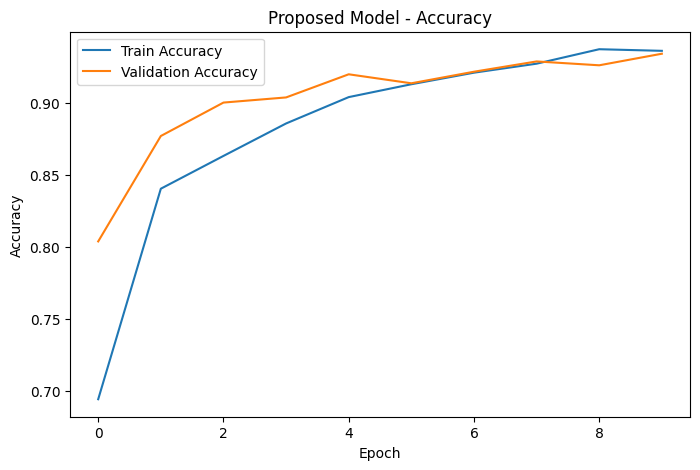

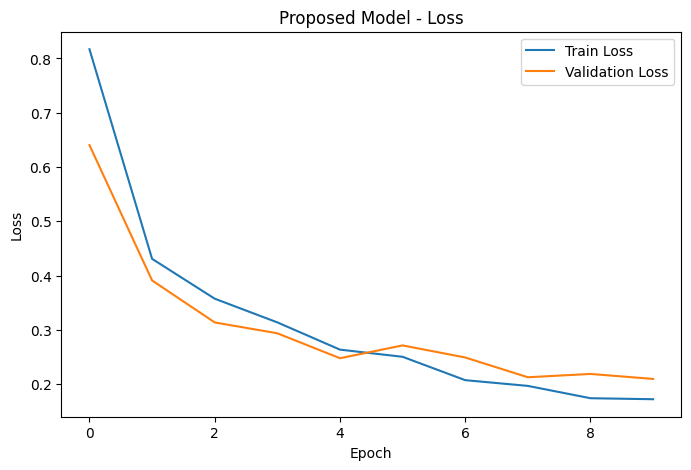

In [ ]:
# Phase 1: train the new attention/classification head with MobileNetV2 frozen.
history_proposed_head = proposed_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    callbacks=get_callbacks(patience=2)
)

# Phase 2: carefully fine-tune the last MobileNetV2 layers.
backbone = proposed_model.get_layer('proposed_mobilenetv2_aug_attention_finetune_backbone')
backbone.trainable = True

# Freeze most of the backbone. Fine-tune only the last 20 layers.
for layer in backbone.layers[:-20]:
    layer.trainable = False

for layer in backbone.layers[-20:]:
    # Keep BatchNorm layers frozen for stability.
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

proposed_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_proposed_finetune = proposed_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=4,
    callbacks=get_callbacks(patience=2)
)

history_proposed = combine_histories(history_proposed_head, history_proposed_finetune)

HISTORIES['Proposed Model'] = history_proposed
plot_history(history_proposed, 'Proposed Model')


Proposed Model Test Accuracy: 0.8544
Proposed Model Test Loss: 0.5032
Classification Report:
              precision    recall  f1-score   support

      glioma     0.9426    0.6975    0.8017       400
  meningioma     0.7912    0.7675    0.7792       400
     notumor     0.9028    0.9750    0.9375       400
   pituitary     0.8079    0.9775    0.8846       400

    accuracy                         0.8544      1600
   macro avg     0.8611    0.8544    0.8508      1600
weighted avg     0.8611    0.8544    0.8508      1600



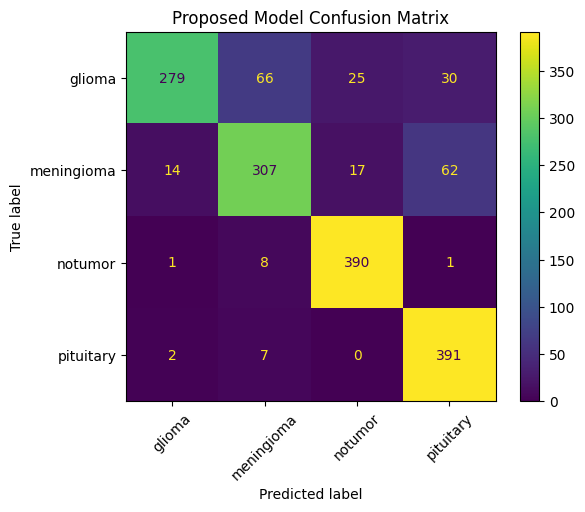

(0.8543750047683716, 0.5032097101211548, 0.8507568349513256)

In [ ]:
evaluate_model(proposed_model, test_ds, 'Proposed Model')

## 12. Ablation Study Results

The ablation study compares the baseline and each added improvement. This directly addresses the final project requirement to show how each modification affects performance.

In [ ]:
# Build a clean comparison table using BOTH best validation accuracy and final test metrics.
# Best validation accuracy is useful for comparing training performance across epochs.
# Test accuracy is the final held-out evaluation metric.

results_df = pd.DataFrame(RESULTS)

best_val_rows = []
for model_name, hist in HISTORIES.items():
    best_val_rows.append({
        'Model': model_name,
        'Best Validation Accuracy': max(hist.history['val_accuracy']),
        'Best Validation Loss': min(hist.history['val_loss'])
    })

best_val_df = pd.DataFrame(best_val_rows)
comparison_df = best_val_df.merge(results_df, on='Model', how='left')
comparison_df = comparison_df.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

display(comparison_df)

# Keep this name so the save cell still works.
results_df = comparison_df


,Model,Best Validation Accuracy,Best Validation Loss,Test Accuracy,Test Loss,Macro F1
0,Baseline + Attention Module,0.958036,0.129424,0.894375,0.422383,0.892421
1,Baseline MobileNetV2,0.940179,0.192135,0.860625,0.456758,0.857298
2,Proposed Model,0.933929,0.209944,0.854375,0.503210,0.850757
3,Baseline + Data Augmentation,0.915179,0.253851,0.830625,0.525396,0.824916


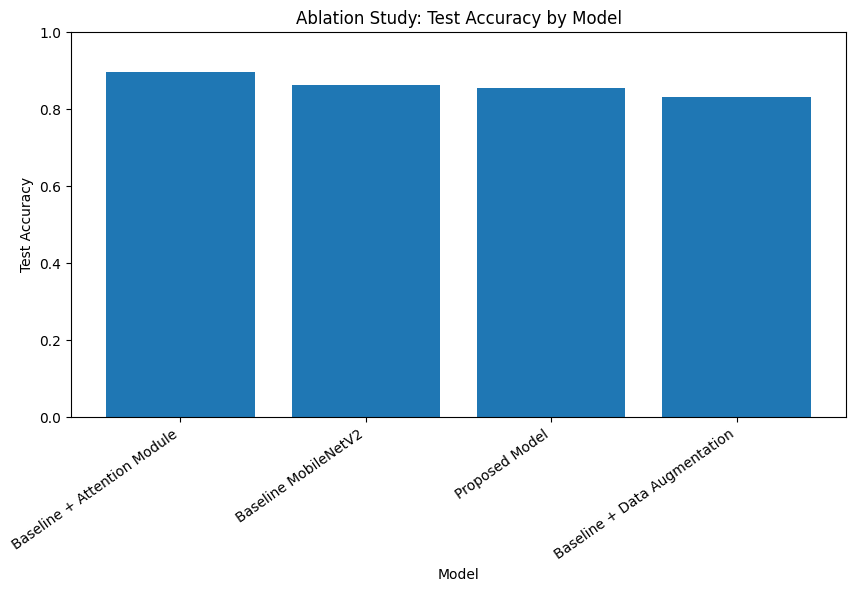

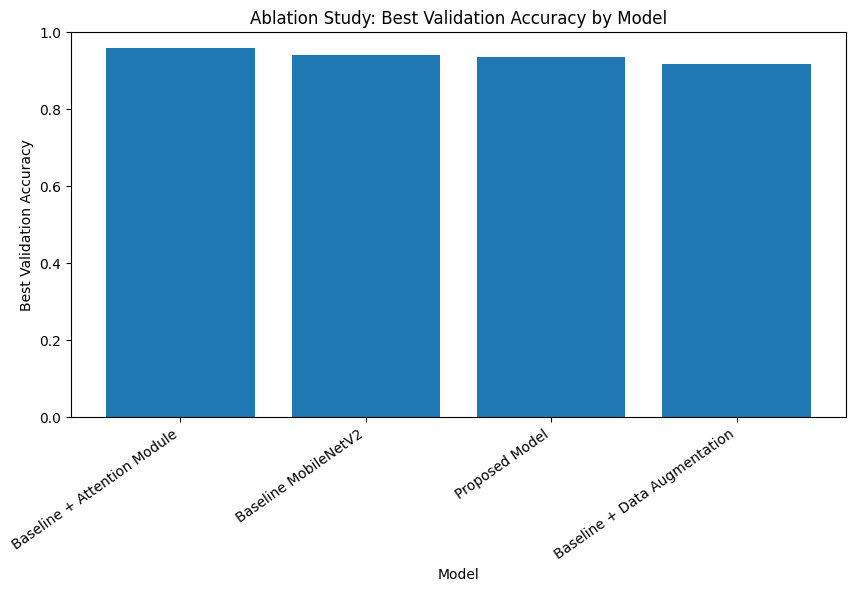

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['Test Accuracy'])
plt.title('Ablation Study: Test Accuracy by Model')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=35, ha='right')
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['Best Validation Accuracy'])
plt.title('Ablation Study: Best Validation Accuracy by Model')
plt.xlabel('Model')
plt.ylabel('Best Validation Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=35, ha='right')
plt.show()


## 13. Save Final Model and Results

This saves the proposed model and the ablation table for use in the final report and presentation.

In [ ]:
OUTPUT_DIR = Path('/content/drive/MyDrive/Brain Tumor Dataset/project_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

proposed_model.save(OUTPUT_DIR / 'proposed_mobilenetv2_brain_tumor_model.keras')
results_df.to_csv(OUTPUT_DIR / 'ablation_results.csv', index=False)

print('Saved model and results to:', OUTPUT_DIR)

Saved model and results to: /content/drive/MyDrive/Brain Tumor Dataset/project_outputs


## 14. Final Notes for Report

Use these points in the written report:

- The task is multiclass brain MRI image classification.
- The dataset contains four classes: glioma, meningioma, pituitary tumor, and no tumor.
- MobileNetV2 was selected as the consistent model family because it is appropriate for image classification and computationally efficient.
- The baseline uses frozen MobileNetV2 features with a new classification head.
- The ablation study compares baseline, data augmentation, attention, and the proposed full model.
- In this improved version, augmentation is intentionally gentle because aggressive transformations can distort MRI images.
- The attention module is a lightweight Squeeze-and-Excitation block that reweights feature channels before classification.
- The proposed model combines augmentation, attention, and careful fine-tuning of only the last MobileNetV2 layers.
- If an individual improvement performs better than the full proposed model, discuss that honestly as an ablation finding. Ablation studies are meant to show which components help and which components may hurt.
